# Replicating Altman (1968): The Z-Score Bankruptcy Model
### U.S.E. Finance Data Hub / WRDS Database: **Compustat North America**

**Paper replicated:** Altman, E. I. (1968). *Financial Ratios, Discriminant Analysis and the Prediction of Corporate Bankruptcy.* The Journal of Finance, 23(4), 589–609.

**Database used:** [Compustat North America](https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/north-america-daily/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/compustat-north-america/))

---

## What this notebook does

Altman's Z-Score is one of the most influential and widely taught models in corporate finance. Using five accounting ratios combined via linear discriminant analysis, it produces a single score that classifies firms into **safe**, **grey-zone**, and **distress** categories based on bankruptcy risk.

The original 1968 study used a small, hand matched sample: 33 bankrupt and 33 non-bankrupt U.S. manufacturing firms (1946–1965), with data collected manually from financial statements. We can't reconstruct that exact matched sample from WRDS, as bankruptcy flagged firm lists aren't in Compustat, but we **can** demonstrate the full empirical machinery of the paper:

1. Pull the underlying financial statement variables straight from **Compustat North America** via the WRDS API
2. Construct all five Altman ratios exactly as defined in the paper
3. Compute the Z-Score for a broad, modern cross-section of firms
4. Classify firms into Altman's three risk zones and visualize the distribution
5. Compare our distribution and coefficients against the published 1968 results, and discuss why (and how) a modern replication differs from the original

## Learning objectives
- Practice connecting to WRDS and querying Compustat fundamentals data with SQL via the `wrds` Python library
- Understand how a foundational empirical finance paper maps onto real Compustat fields
- Build intuition for financial ratio construction, data cleaning choices (e.g., excluding financial firms), and how sample construction choices affect results

## Requirements to run this notebook
- A valid **WRDS account** with Compustat North America access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn`
- You will be prompted for your WRDS username/password the first time you connect (Or set up a `.pgpass` file. See the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

# Connecting to WRDS will prompt for your WRDS username and password
# (or read them from a stored .pgpass file if you've configured one).
db = wrds.Connection()

Enter your WRDS username [antho]:sunho2000
Enter your password:········


OperationalError: (psycopg2.OperationalError) connection to server at "wrds-pgdata.wharton.upenn.edu" (165.123.60.118), port 9737 failed: FATAL:  PAM authentication failed for user "sunho2000"

(Background on this error at: https://sqlalche.me/e/20/e3q8)

## 2. Identifying the Compustat variables we need

Altman's five ratios require the following raw Compustat fields, all available in the **`comp.funda`** table (Compustat North America > Fundamentals Annual):

| Altman component | Formula | Compustat field(s) |
|---|---|---|
| Working Capital | Current Assets − Current Liabilities | `act`, `lct` |
| Total Assets | — | `at` |
| Retained Earnings | — | `re` |
| EBIT | Earnings Before Interest and Taxes | `ebit` |
| Market Value of Equity | Share price × shares outstanding | `prcc_f`, `csho` |
| Total Liabilities | — | `lt` |
| Sales | Net Sales/Revenue | `sale` |

We also pull `sich` (historical SIC code), `fyear` (fiscal year), `conm` (company name), and `gvkey` (Compustat firm identifier) for filtering and labeling.

**Sample restriction, following Altman's original design:** Altman's model was built and validated on **manufacturing firms**. Financial firms (banks, insurers) have fundamentally different balance sheet structures (e.g., "current assets/liabilities" is not a meaningful concept for a bank), so we exclude SIC codes 6000–6999 just as the finance literature conventionally does when applying this model outside financials.


In [7]:
# Pull the most recent fiscal year of data (adjust the year range as you like).
# 'indfmt' = INDL (industrial format), 'datafmt' = STD, 'consol' = C, 'popsrc' = D
# are the standard filters WRDS recommends to avoid duplicate/restated records.
#
# NOTE: In comp.funda the SIC code column is called 'sich' (historical SIC),
# not 'sic'. The plain 'sic' column only exists in the comp.company header table.

query = """
    SELECT gvkey, conm, fyear, datadate, sich,
           at, lt, act, lct, re, ebit, sale,
           prcc_f, csho
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND consol = 'C'
      AND popsrc = 'D'
      AND fyear BETWEEN 2019 AND 2023
"""

df = db.raw_sql(query)
print(f"Rows pulled: {len(df):,}")
df.head()


Rows pulled: 61,057


,gvkey,conm,fyear,datadate,sich,at,lt,act,lct,re,ebit,sale,prcc_f,csho
0,001004,AAR CORP,2019,2020-05-31,5080,2079.0,1176.4,1438.7,383.1,661.4,106.4,2089.3,20.17,35.097
1,001019,AFA PROTECTIVE SYSTEMS INC,2019,2019-12-31,7380,33.355,21.722,23.727,16.881,8.416,3.245,83.088,180.0,0.162
2,001045,AMERICAN AIRLINES GROUP INC,2019,2019-12-31,4512,59995.0,60113.0,8206.0,18311.0,-4067.0,3706.0,45768.0,28.68,428.203
3,001050,CECO ENVIRONMENTAL CORP,2019,2019-12-31,3564,408.637,215.62,179.498,115.188,-60.849,19.622,341.869,7.66,35.137
4,001062,ASA GOLD AND PRECIOUS METALS,2019,2019-11-30,6799,286.612,0.733,<NA>,<NA>,265.216,-1.173,2.371,12.2,19.29


## 3. Cleaning the sample

In [8]:
# Drop rows missing any of the fields we need for the Z-Score calculation.
# We keep sich missing rows for now and handle them separately below,
# since some firms may simply lack a historical SIC code.
zscore_cols = ["at", "lt", "act", "lct", "re", "ebit", "sale", "prcc_f", "csho"]
df = df.dropna(subset=zscore_cols)

# Exclude financial firms (historical SIC 6000-6999)
# sich is numeric in Compustat; firms with missing sich are kept (conservative choice).
df = df[~((df["sich"] >= 6000) & (df["sich"] < 7000))]

# Exclude non-positive total assets (data errors) and take one observation per firm-year
df = df[df["at"] > 0]
df = df.drop_duplicates(subset=["gvkey", "fyear"])

print(f"Rows after cleaning: {len(df):,}")
print(f"Unique firms: {df['gvkey'].nunique():,}")


Rows after cleaning: 23,406
Unique firms: 6,091


## 4. Constructing the Altman Z-Score

Altman's original (1968) discriminant function for publicly traded manufacturing firms:

$$Z = 1.2 X_1 + 1.4 X_2 + 3.3 X_3 + 0.6 X_4 + 1.0 X_5$$

Where:
- $X_1$ = Working Capital / Total Assets → liquidity relative to firm size
- $X_2$ = Retained Earnings / Total Assets → cumulative profitability / firm age & leverage history
- $X_3$ = EBIT / Total Assets → operating profitability, independent of tax/leverage effects
- $X_4$ = Market Value of Equity / Total Liabilities → market-based solvency (how far assets can fall before liabilities exceed value)
- $X_5$ = Sales / Total Assets → asset turnover / competitive positioning

**Classification zones** (from the paper):
- $Z > 2.99$ → **"Safe" zone**: low bankruptcy probability
- $1.81 \le Z \le 2.99$ → **"Grey" zone**: ambiguous
- $Z < 1.81$ → **"Distress" zone**: high bankruptcy probability


In [9]:
df["mve"] = df["prcc_f"] * df["csho"]  # Market value of equity

df["X1"] = (df["act"] - df["lct"]) / df["at"]
df["X2"] = df["re"] / df["at"]
df["X3"] = df["ebit"] / df["at"]
df["X4"] = df["mve"] / df["lt"]
df["X5"] = df["sale"] / df["at"]

df["Z"] = 1.2*df["X1"] + 1.4*df["X2"] + 3.3*df["X3"] + 0.6*df["X4"] + 1.0*df["X5"]

def classify_zone(z):
    if z > 2.99:
        return "Safe"
    elif z >= 1.81:
        return "Grey"
    else:
        return "Distress"

df["zone"] = df["Z"].apply(classify_zone)

df[["conm", "fyear", "X1", "X2", "X3", "X4", "X5", "Z", "zone"]].sort_values("Z").head(10)


,conm,fyear,X1,X2,X3,X4,X5,Z,zone
19629,CAMROVA RESOURCES INC,2020,-497.5,-218571.0,-173.5,0.127596,0.0,-307168.873443,Distress
60841,BIOFORCE NANOSCIENCES HLDGS,2023,-1819.0,-160630.0,-472.0,32.327868,0.0,-228603.003279,Distress
48175,BIOFORCE NANOSCIENCES HLDGS,2022,-1347.0,-160157.0,-486.0,43.213116,0.0,-227414.072131,Distress
14186,BURZYNSKI RESEARCH INSTITUTE,2020,-46.0,-124862.0,-1302.0,81.106213,0.0,-179109.936272,Distress
27522,NUNZIA PHARMACEUTICAL CO,2021,-19.8,-35876.2,-15612.2,2850.721333,0.0,-100060.2672,Distress
45493,GLOBAL DIGITAL SOLUTIONS INC,2022,-16075.0,-55111.0,-427.0,1.239957,0.0,-97853.756026,Distress
2869,AMERICAN NOBLE GAS INC,2019,-6608.0,-61401.0,-209.5,0.072642,0.0,-94582.306415,Distress
546,BIOSTAX CORP,2019,-2281.666667,-64099.5,-473.0,0.217178,0.0,-94038.069693,Distress
50612,BURZYNSKI RESEARCH INSTITUTE,2023,-12.5,-64045.0,-667.5,111.925538,0.0,-91813.594677,Distress
38142,BURZYNSKI RESEARCH INSTITUTE,2022,-7.0,-63377.5,-458.0,301.919625,0.0,-90067.148225,Distress


## 5. Visualizing the results

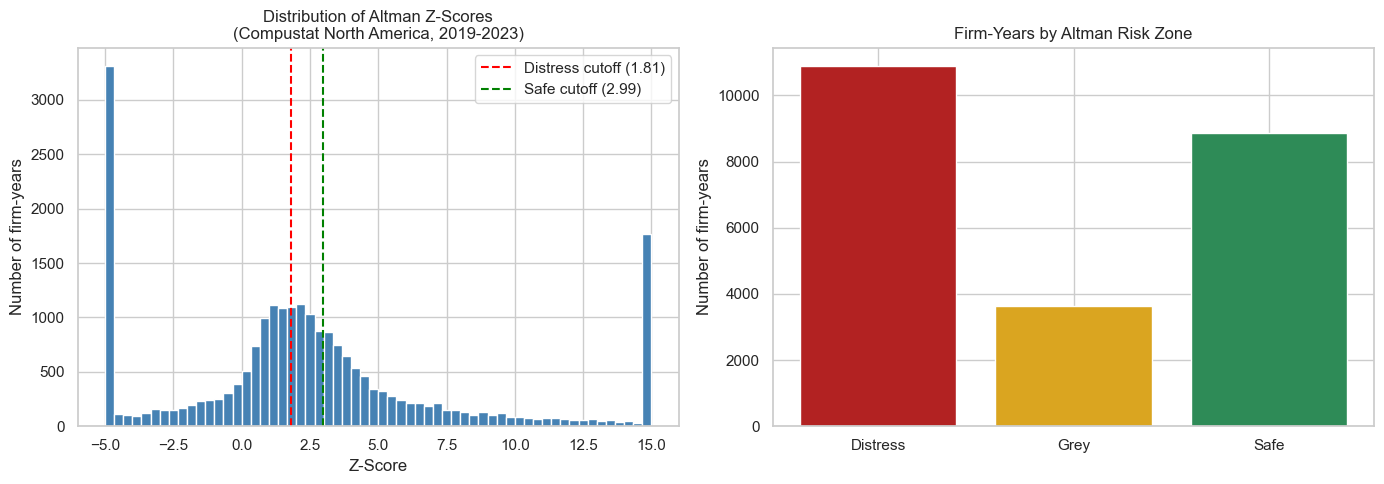

zone
Distress    10892
Grey         3639
Safe         8875
Name: count, dtype: int64

Share in distress zone: 46.5%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Z-scores, clipped for readability
z_clipped = df["Z"].clip(-5, 15)
axes[0].hist(z_clipped, bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(1.81, color="red", linestyle="--", label="Distress cutoff (1.81)")
axes[0].axvline(2.99, color="green", linestyle="--", label="Safe cutoff (2.99)")
axes[0].set_title("Distribution of Altman Z-Scores\n(Compustat North America, 2019-2023)")
axes[0].set_xlabel("Z-Score")
axes[0].set_ylabel("Number of firm-years")
axes[0].legend()

# Zone counts
zone_counts = df["zone"].value_counts().reindex(["Distress", "Grey", "Safe"])
axes[1].bar(zone_counts.index, zone_counts.values,
            color=["firebrick", "goldenrod", "seagreen"])
axes[1].set_title("Firm-Years by Altman Risk Zone")
axes[1].set_ylabel("Number of firm-years")

plt.tight_layout()
plt.show()

print(zone_counts)
print(f"\nShare in distress zone: {zone_counts['Distress'] / zone_counts.sum():.1%}")


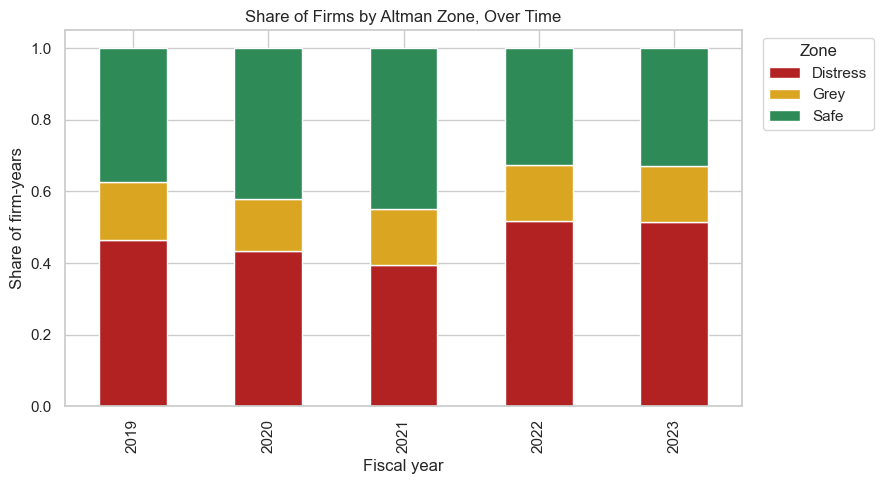

In [11]:
# Trend over time: share of firms in each zone by fiscal year
zone_by_year = (
    df.groupby(["fyear", "zone"]).size()
      .unstack(fill_value=0)
      .reindex(columns=["Distress", "Grey", "Safe"])
)
zone_share = zone_by_year.div(zone_by_year.sum(axis=1), axis=0)

zone_share.plot(kind="bar", stacked=True, figsize=(9, 5),
                 color=["firebrick", "goldenrod", "seagreen"])
plt.title("Share of Firms by Altman Zone, Over Time")
plt.ylabel("Share of firm-years")
plt.xlabel("Fiscal year")
plt.legend(title="Zone", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6. Comparing to Altman (1968): What's the same, what's different

**What replicates cleanly:**
- The five ratios and their combination formula are exactly as specified in the original paper. This is the core empirical contribution and it maps directly onto standard Compustat fields.
- The classification cutoffs (1.81 / 2.99) are Altman's own published thresholds and are still the industry standard reference points taught today.

**Where a modern WRDS-based replication necessarily differs from the original:**
1. **Sample construction.** Altman used a *matched sample* of exactly 33 bankrupt and 33 healthy manufacturing firms, selected specifically to validate a discriminant model. We instead pulled a broad, unmatched cross section of all manufacturing-adjacent firms in Compustat over a modern period, there is no bankruptcy flag field in Compustat, so we cannot reconstruct his exact treatment/control design without an external bankruptcy database (e.g., the WRDS/Wharton bankruptcy datasets or SEC filings).
2. **Model re-estimation vs. application.** Altman's paper *derives* the coefficients (1.2, 1.4, 3.3, 0.6, 1.0) via linear discriminant analysis on his matched sample. We *apply* his already-published coefficients to new data rather than re-estimating them. Re-estimating would require the bankrupt/non-bankrupt labels mentioned above.
3. **Time period and economy.** 1946 ~ 1965 U.S. manufacturing looked very different (capital intensity, leverage norms, accounting standards) from firms today, so the cross-sectional distribution of Z-scores will differ even if the formula is identical.
4. **Data source.** Altman collected data by hand from financial statements; Compustat standardizes and restates historical data, which can shift ratios at the margin (e.g., restated `re` or `at` values).

---

## References
- Altman, E. I. (1968). Financial Ratios, Discriminant Analysis and the Prediction of Corporate Bankruptcy. *The Journal of Finance*, 23(4), 589–609.
- WRDS Compustat North America guide: https://uufinance.github.io/data/wrds/databases/compustat-north-america/
- WRDS Compustat North America access page: https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/north-america-daily/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
